Programa de ML para predecir si un paciente tiene diabetes o no. Dataset obtenido de https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database?select=diabetes.csv. SON TODO MUJERES DE UNA CIERTA RAZA.

In [3]:
import pandas as pd
import numpy as np

In [4]:
data = pd.read_csv("C:\\Users\\alvar\\OneDrive\\Escritorio\\PROYECTOS\\Python\\MLJupyter\\diabetes.csv")

## Gestión inicial de datos 

In [5]:
data.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [6]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Si es "1" es que tiene diabetes, "0" si no la tiene.

- La DPF es una función relacionada con el número de familiares afectados por diabetes, el grado de parentesco de estos afectados con el paciente, y el tamaño de la familia.

- El BMI en inglés es el IMC en español.

- La SkinThickness se refiere al espesor del pliegue cutáneo tricipital: es una medida en milímetros (mm), se toma con un plicómetro en la parte posterior del brazo (tríceps) y representa la cantidad de grasa subcutánea de una persona.

LOS VALORES NULOS SIGNIFICAN QUE FALTA EL DATO (excepto en las columnas de pregnancies y outcome).

## Tratamiento de datos

Aquí separo el dataset en y, X.

In [7]:
# y_data = data.Outcome
# X_data = data[['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']]

Aquí miro el tamaño de la tabla de datos y la cantidad de 0's que aparecen en cada tabla.

In [8]:
# Shape of training data (num_rows, num_columns)
print(data.shape)

(data == 0).sum()

(768, 9)


Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

Obviamente no nos importa que en Pregnancies o en Outcome haya un cero. Vamos a tener que imputar las columnas que sí que tienen 0's (G, BP, ST, I, BMI).

Vamos a ver también si hay algún hueco vacío "NaN" en esta tabla de datos:

In [9]:
# Number of missing values in each column of training data
missing_val_count_by_column_train = (data.isnull().sum())
print(missing_val_count_by_column_train[missing_val_count_by_column_train > 0])

Series([], dtype: int64)


NO HAY HUECOS VACÍOS.

Antes de imputar datos vamos a estudiar la correlación que hay entre ellos para saber que ténica de imputación usar. La correlaciones van entre -1 y 1 tal que:
- Correlación positiva: Cuando una de las variables aumenta la otra tiende a aumentar también.
- Correlación negativa:  Cuando una de las variables aumenta la otra tiende a disminuir. 
- Correlación 0: No hay ninguna relación lineal entre variables. 

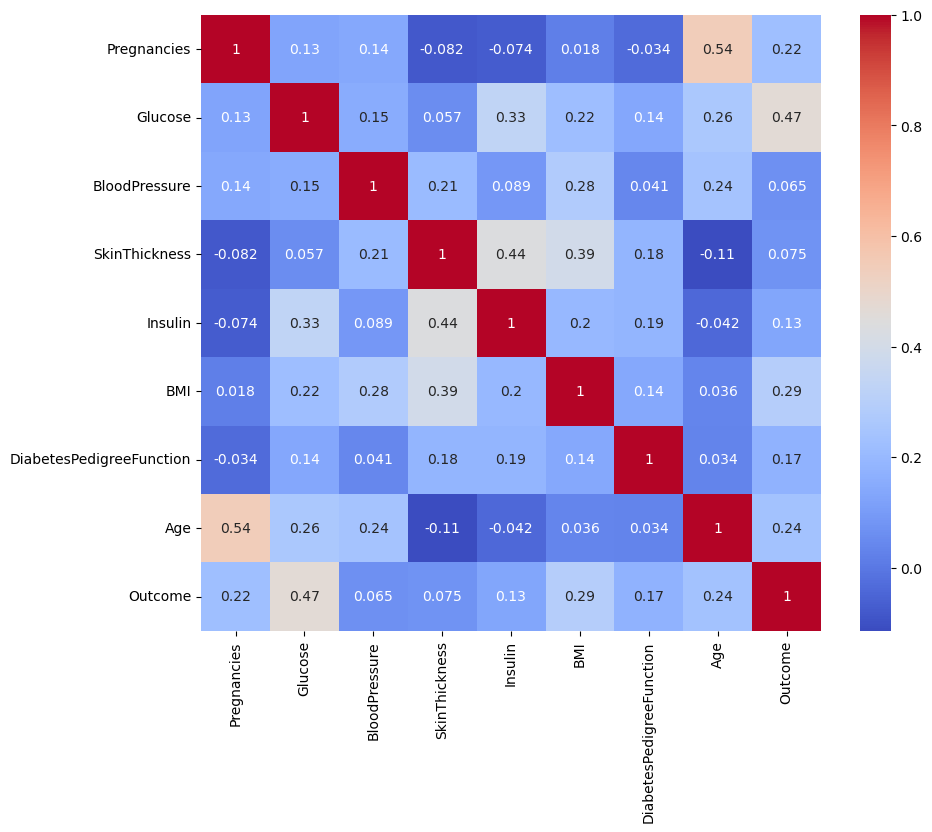

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.show()

Todas las filas en las que ST es 0, en Insulin también hay un cero. Tal vez lo mejor sea quitar todas estas filas para evitar suponer cosas.

In [11]:
print("Número de filas con ST e Insulin = 0:", ((data["SkinThickness"] == 0) & (data["Insulin"] == 0)).sum() )

Número de filas con ST e Insulin = 0: 227


In [12]:
data = data[~((data["SkinThickness"] == 0) & (data["Insulin"] == 0))]

(data == 0).sum()

Pregnancies                  79
Glucose                       5
BloodPressure                 2
SkinThickness                 0
Insulin                     147
BMI                           2
DiabetesPedigreeFunction      0
Age                           0
Outcome                     361
dtype: int64

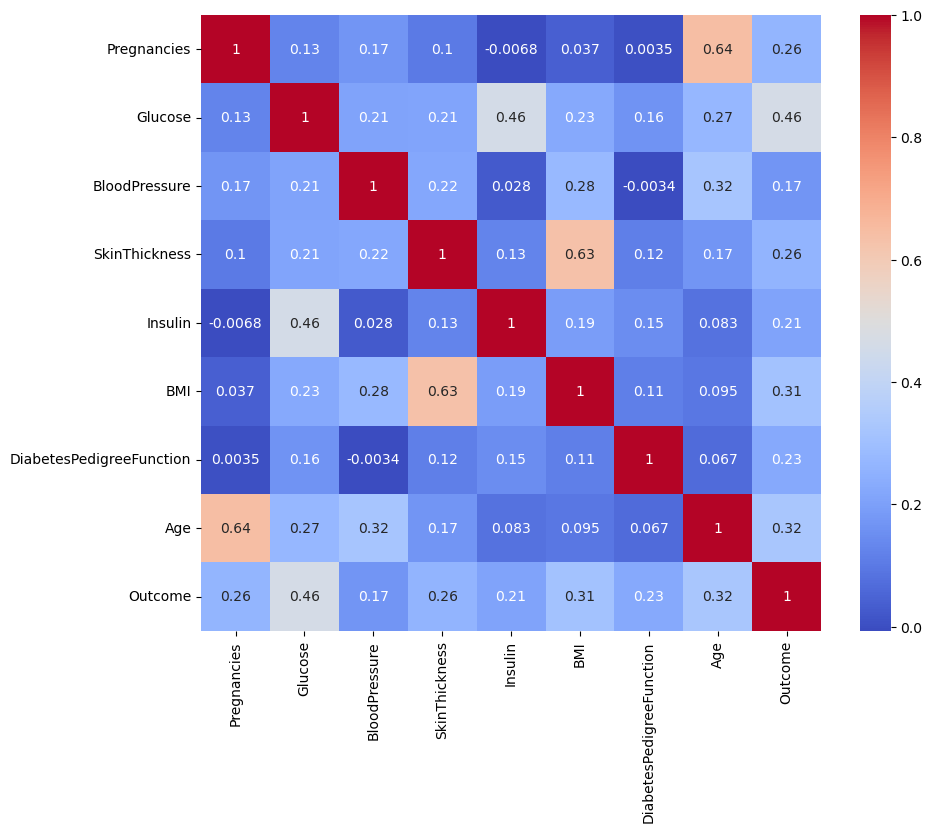

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.show()

Hay una fuerte correlación positiva entre Outcome,Insulin y Glucose, como es lógico, así que podemos imputar la columna de Glucose con la mediana separando por Outcomes (No imputamos con Insulin ya que esta columna está muy vacía). 

In [14]:
# Calcular la mediana de Glucose ignorando ceros
median_glucose = data.loc[data["Glucose"] != 0].groupby("Outcome")["Glucose"].median()

# imputo los ceros
data["Glucose"] = data["Glucose"].mask(data["Glucose"] == 0, data["Outcome"].map(median_glucose))

Confirmamos que la Glucose ha sido imputada. 

In [15]:
(data == 0).sum()

Pregnancies                  79
Glucose                       0
BloodPressure                 2
SkinThickness                 0
Insulin                     147
BMI                           2
DiabetesPedigreeFunction      0
Age                           0
Outcome                     361
dtype: int64

Para la columna de BMI podemos rellenar los 0's con la mediana y ya está (solo son 2 ceros de unos 500 datos).

In [16]:
# Calcular la mediana ignorando los ceros
median_BMI = data.loc[data["BMI"] != 0, "BMI"].median()

# Reemplazar ceros por la mediana
data["BMI"] = data["BMI"].replace(0, median_BMI)

Confirmamos que el BMI ha sido imputado:

In [17]:
(data == 0).sum()

Pregnancies                  79
Glucose                       0
BloodPressure                 2
SkinThickness                 0
Insulin                     147
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     361
dtype: int64

Vemos que la BP está directamente relacionada con Age y BMI, a si que podemos imputar con la mediana los huecos con 0's y clasificar por edades y BMI. Lo que pasa es que Age y BMI es un rango continuo, a si que hay que clasificar por bines. Para ello hay que ver los rangos que hay que tomar.

In [18]:
print('Age mínimo:',data['Age'].min())
print('Age máximo:',data['Age'].max())

print('BMI mínimo:',data['BMI'].min())
print('BMI máximo:',data['BMI'].max())

Age mínimo: 21
Age máximo: 81
BMI mínimo: 18.2
BMI máximo: 67.1


Podemos hacer bines de 10 en 10, desde 20 hasta 80. Si Age = 21, entonces Age_bin = 0; si Age = 34, Age_bin = 1; etc.

In [19]:
data["Age_bin"] = pd.cut(data["Age"], bins=[20,30,40,50,60,70,80], labels=False)
data["BMI_bin"] = pd.cut(data["BMI"], bins=[15,25,35,45,55,65], labels=False)

# Calcular mediana de BP por grupo
median_BP = (data[data["BloodPressure"] != 0].groupby(["Age_bin", "BMI_bin"])["BloodPressure"].median())

# Función para imputar
def fill_BP(row):
    if row["BloodPressure"] == 0:
        # .get devuelve la mediana del bin o la mediana global si no existe
        return median_BP.get((row["Age_bin"], row["BMI_bin"]), data["BloodPressure"].median())
    else:
        return row["BloodPressure"]

# Aplicar imputación
data["BloodPressure"] = data.apply(fill_BP, axis=1)

In [20]:
(data == 0).sum()

Pregnancies                  79
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                     147
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     361
Age_bin                     327
BMI_bin                      65
dtype: int64

Vamos a ver si ha cambiado algo del heatmap:

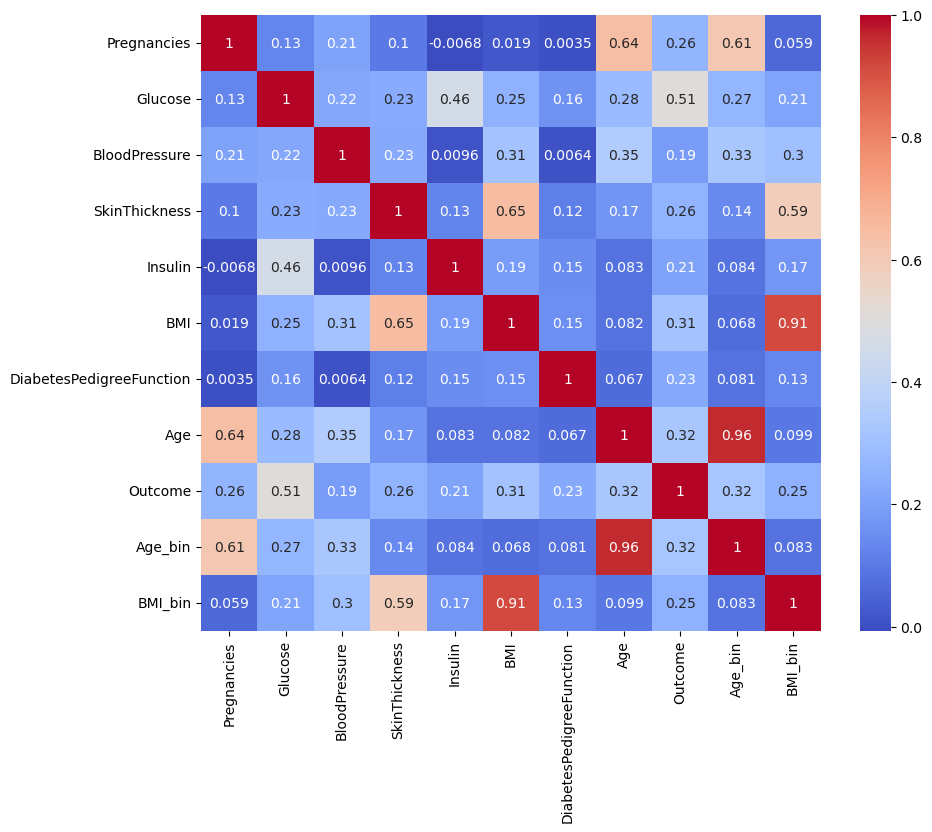

In [21]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.show()

Tal vez podamos imputar la Insulin con la Glucose teniendo en cuenta esta fuerte correlación positiva. 

In [22]:
print('Glucose mínimo:',data['Glucose'].min())
print('Glucose máximo:',data['Glucose'].max())

Glucose mínimo: 56
Glucose máximo: 199


In [23]:
data["Glucose_bin"] = pd.cut(data["Glucose"], bins=[50,75,100,125,150,175], labels=False)

# Calcular mediana de Insul por grupo
median_Insul = (data[data["Insulin"] != 0].groupby(["Glucose_bin"])["Insulin"].median())

# Función para imputar
def fill_Insul(row):
    if row["Insulin"] == 0:
        # .get devuelve la mediana del bin o la mediana global si no existe
        return median_Insul.get((row["Glucose_bin"]), data["Insulin"].median())
    else:
        return row["Insulin"]

# Aplicar imputación
data["Insulin"] = data.apply(fill_Insul, axis=1)

In [24]:
(data == 0).sum()

Pregnancies                  79
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     361
Age_bin                     327
BMI_bin                      65
Glucose_bin                  16
dtype: int64

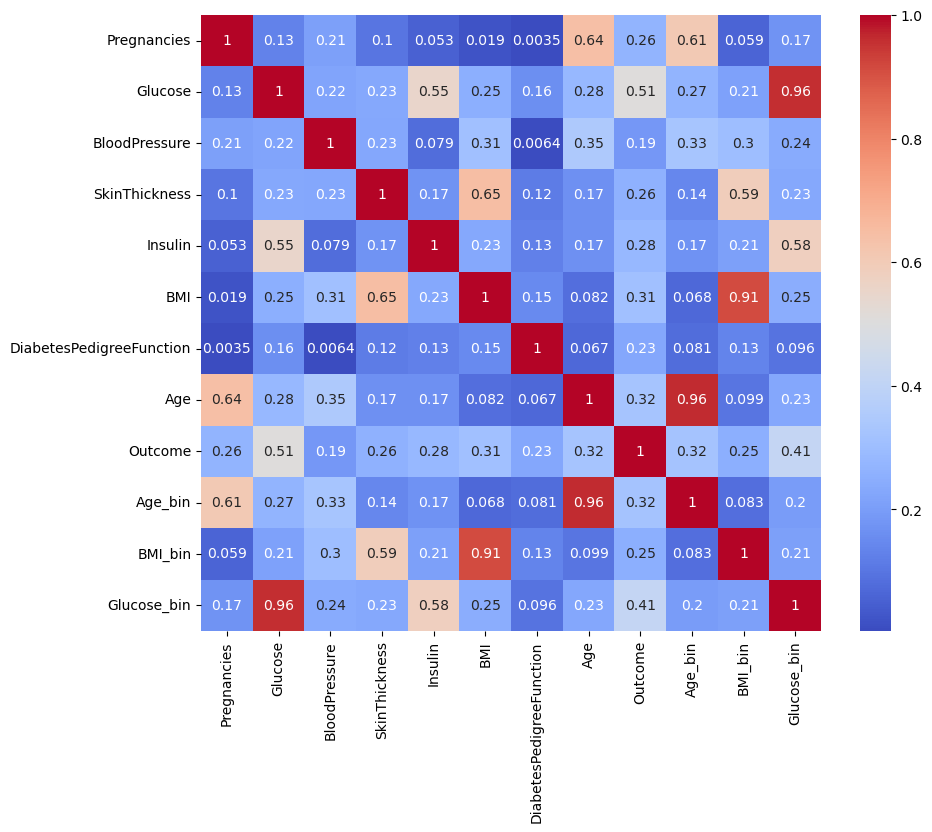

In [25]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.show()

## Normalización de los datos

In [26]:
from sklearn.preprocessing import MinMaxScaler #Para normalizar los datos entre 0 y 1

# Selecciona solo columnas numéricas
cols = data.select_dtypes(include=['float64', 'int64']).columns

# Inicializa el scaler
scaler = MinMaxScaler()

# Escala las columnas y reemplaza en el DataFrame
data[cols] = scaler.fit_transform(data[cols])

In [27]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Age_bin,BMI_bin,Glucose_bin
0,0.352941,0.643357,0.558140,0.304348,0.178486,0.314928,0.232120,0.483333,1.0,0.50,0.25,0.75
1,0.058824,0.202797,0.488372,0.239130,0.068510,0.171779,0.113919,0.166667,0.0,0.25,0.25,0.25
3,0.058824,0.230769,0.488372,0.173913,0.096154,0.202454,0.035118,0.000000,0.0,0.00,0.25,0.25
4,0.000000,0.566434,0.186047,0.304348,0.185096,0.509202,0.943469,0.200000,1.0,0.25,0.50,0.75
6,0.176471,0.153846,0.302326,0.271739,0.088942,0.261759,0.069807,0.083333,1.0,0.00,0.25,0.25


## Decision Tree

In [28]:
X_data = data[['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']]
y_data = data.Outcome

In [29]:
from sklearn.model_selection import train_test_split

# Dividimos el train original en train + valid
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42)
#test_size = 0.1 implica que el 10% de X_data va para X_valid (test)

In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Modelo base
#rf = DecisionTreeClassifier(random_state=42)

# Espacio de hiperparámetros
#param_dist = {
#    "max_depth": randint(3, 30),               # profundidad máxima
#    "min_samples_split": randint(2, 20),       # mínimo de muestras para dividir
#    "min_samples_leaf": randint(1, 20),        # mínimo de muestras en una hoja
#    "max_features": ["sqrt", "log2", None],    # número de features a usar
#    "criterion": ["gini", "entropy", "log_loss"],  # criterio de impureza
#    "max_leaf_nodes": randint(10, 1000)         # máximo número de hojas por árbol
#}

# Configuración de RandomizedSearchCV
#random_search = RandomizedSearchCV(
#    estimator=rf,
#    param_distributions=param_dist,
#    n_iter=50,              # número de combinaciones a probar
#    cv=5,                   # validación cruzada
#    scoring="accuracy",     # métrica de evaluación
#    random_state=42,
#    n_jobs=-1,              # usar todos los núcleos disponibles
#    verbose=1
#)

# Entrenamiento
#random_search.fit(X_train, y_train)

# Resultados
#print("Mejores hiperparámetros:", random_search.best_params_)
#print("Mejor score:", random_search.best_score_)

In [31]:
diabetes_dtmodel = DecisionTreeClassifier(
    max_leaf_nodes=1000,
    random_state=1,
    criterion='entropy',
    max_depth=5,
    min_samples_split=3,
    min_samples_leaf=5,
)

diabetes_dtmodel.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, max_leaf_nodes=1000,
                       min_samples_leaf=5, min_samples_split=3, random_state=1)

In [32]:
predictions_dtmodel = diabetes_dtmodel.predict(X_test)

from sklearn.metrics import accuracy_score

# Suponiendo que y_test y predictions son arrays/listas
accuracy_rfmodel = accuracy_score(y_test, predictions_dtmodel) * 100
print(f"Porcentaje de aciertos: {accuracy_rfmodel:.2f}%")

Porcentaje de aciertos: 72.48%


## XGboost

In [33]:
# Dividimos el train original en train + valid
X_train_new, X_valid, y_train_new, y_valid = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [34]:
#from xgboost import XGBClassifier
#from sklearn.model_selection import RandomizedSearchCV
#from scipy.stats import randint, uniform

# Modelo base
#xgb = XGBClassifier(
#    random_state=42,
#    use_label_encoder=False,
#    eval_metric="logloss"   # evita warnings
#)

# Espacio de hiperparámetros
#param_dist = {
#    "n_estimators": randint(100, 1000),        # número de árboles
#    "max_depth": randint(3, 15),               # profundidad máxima
#    "learning_rate": uniform(0.01, 0.3),       # tasa de aprendizaje
#    "subsample": uniform(0.6, 0.4),            # proporción de muestras
#    "colsample_bytree": uniform(0.6, 0.4),     # proporción de features
#    "gamma": uniform(0, 5),                    # regularización mínima para dividir
#    "min_child_weight": randint(1, 10),        # peso mínimo de hojas
#    "scale_pos_weight": [1, 2, 5, 10]          # útil si las clases están desbalanceadas
#}

# Configuración de RandomizedSearchCV
#random_search = RandomizedSearchCV(
#    estimator=xgb,
#    param_distributions=param_dist,
#    n_iter=50,               # número de combinaciones a probar
#    scoring="f1",            # mejor que accuracy en problemas médicos
#    cv=5,                    # validación cruzada
#    verbose=1,
#    random_state=42,
#    n_jobs=-1
#)

# Entrenar
#random_search.fit(X_train_new, y_train_new)

# Resultados
#print("Mejores hiperparámetros:", random_search.best_params_)
#print("Mejor score:", random_search.best_score_)

In [35]:
from xgboost import XGBClassifier

diabetes_xgmodel = XGBClassifier(
    n_estimators=600,        # número de árboles
    learning_rate=0.05,      # tamaño de los pasos de boosting
    max_depth=8,             # profundidad máxima de cada árbol
    subsample=0.9,           # fracción de datos por árbol
    colsample_bytree=0.7,    # fracción de features por árbol
    use_label_encoder=False,
    eval_metric="logloss",
    early_stopping_rounds=50, 
    verbose=False,
    objective="binary:logistic",
    min_child_weight= 7,
    gamma = 4)

diabetes_xgmodel.fit(X_train_new, y_train_new, eval_set=[(X_valid, y_valid)])

[0]	validation_0-logloss:0.59701
[1]	validation_0-logloss:0.59051
[2]	validation_0-logloss:0.57929
[3]	validation_0-logloss:0.56925
[4]	validation_0-logloss:0.55884
[5]	validation_0-logloss:0.54756
[6]	validation_0-logloss:0.54236
[7]	validation_0-logloss:0.53487
[8]	validation_0-logloss:0.52970
[9]	validation_0-logloss:0.52682
[10]	validation_0-logloss:0.52368
[11]	validation_0-logloss:0.51870
[12]	validation_0-logloss:0.51260
[13]	validation_0-logloss:0.50668
[14]	validation_0-logloss:0.50381
[15]	validation_0-logloss:0.50286
[16]	validation_0-logloss:0.49766
[17]	validation_0-logloss:0.49324
[18]	validation_0-logloss:0.48897
[19]	validation_0-logloss:0.48476
[20]	validation_0-logloss:0.48335
[21]	validation_0-logloss:0.47909
[22]	validation_0-logloss:0.47492
[23]	validation_0-logloss:0.47114
[24]	validation_0-logloss:0.46603
[25]	validation_0-logloss:0.46690
[26]	validation_0-logloss:0.46360
[27]	validation_0-logloss:0.46067
[28]	validation_0-logloss:0.45826
[29]	validation_0-loglos

c:\Users\alvar\anaconda3\Lib\site-packages\xgboost\callback.py:386: UserWarning: [20:15:25] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder", "verbose" } are not used.

  self.starting_round = model.num_boosted_rounds()


[104]	validation_0-logloss:0.42226
[105]	validation_0-logloss:0.42228
[106]	validation_0-logloss:0.42224
[107]	validation_0-logloss:0.42224
[108]	validation_0-logloss:0.42175
[109]	validation_0-logloss:0.42176
[110]	validation_0-logloss:0.42177
[111]	validation_0-logloss:0.42174
[112]	validation_0-logloss:0.42178
[113]	validation_0-logloss:0.42180
[114]	validation_0-logloss:0.42180
[115]	validation_0-logloss:0.42182
[116]	validation_0-logloss:0.42179
[117]	validation_0-logloss:0.42179
[118]	validation_0-logloss:0.42179
[119]	validation_0-logloss:0.42179
[120]	validation_0-logloss:0.42183
[121]	validation_0-logloss:0.42246
[122]	validation_0-logloss:0.42249
[123]	validation_0-logloss:0.42245
[124]	validation_0-logloss:0.42248
[125]	validation_0-logloss:0.42249
[126]	validation_0-logloss:0.42250
[127]	validation_0-logloss:0.42246
[128]	validation_0-logloss:0.42250
[129]	validation_0-logloss:0.42252
[130]	validation_0-logloss:0.42253
[131]	validation_0-logloss:0.42250
[132]	validation_0-l

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=50,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=4,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=7, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=600, n_jobs=None,
              num_parallel_tree=None, ...)

In [36]:
predictions_xgmodel = diabetes_xgmodel.predict(X_test)

# Suponiendo que y_test y predictions son arrays/listas
accuracy_xgmodel = accuracy_score(y_test, predictions_xgmodel) * 100
print(f"Porcentaje de aciertos: {accuracy_xgmodel:.2f}%")

Porcentaje de aciertos: 80.73%


## Otras cosas

In [40]:
data['DiabetesPedigreeFunction'].median() # Mediana entre 0 y 1

0.14218415417558886

In [42]:
data['DiabetesPedigreeFunction'].mean() # Media entre 0 y 1

np.float64(0.17980739925667039)

In [43]:
data['DiabetesPedigreeFunction'].std()

0.14845336029091763